In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import ssl
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

We load the MNIST dataset directly from OpenML using sklearn's fetch_openml function. This avoids manual file handling and gives us the data in a ready-to-use format. 

Note: SSL verification is temporarily disabled to work around a certificate issue on macOS — we considered that this is acceptable for a local learning project but would not be appropriate in a production environment.

In [ ]:
ssl._create_default_https_context = ssl._create_unverified_context
data = fetch_openml("mnist_784", as_frame=False)

Before training a model, we explore the dataset to verify its structure. 
We check that the features matrix contains 70,000 images of 784 pixels each (28×28), and that the labels vector contains one value per image — the digit it represents (0 to 9).

In [ ]:
print(f"The shape of the features is: {data.data.shape}")
print(f"The shape of the labels is: {data.target.shape}")

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
The shape of the features is: (70000, 784)
The shape of the labels is: (70000,)


We split the dataset into a training set and a test set — both features and labels. 
The model will learn from the training set and be evaluated on the test set, which it will never see during training. We follow the original split defined by Yann LeCun: 60,000 images for training and 10,000 for testing. This also allows our results to be compared with other models benchmarked on MNIST.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size = 10000, train_size = 60000)

Pixel values originally range from 0 (black) to 255 (white). To prevent large numerical values from distorting the model's calculations, we normalize them to a 0-1 scale by dividing by 255. This is a standard preprocessing step in machine learning.

In [6]:
X_train = X_train/255
X_test = X_test/255

As a sanity check, we verify that the data is correctly structured before training. Each image is stored as a flat array of 784 pixel values — we reshape teh first one into a 28×28 matrix using reshape(28, 28) to reconstruct the original 2D image, then display it as gray levels with matplotlib. 

We compare the result visually with its label to confirm the data is coherent.

6


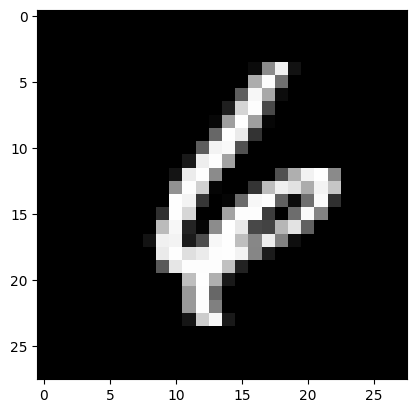

In [29]:
plt.imshow(X_train[1].reshape(28, 28), cmap='gray')
print(y_train[1])


We use Logistic Regression as our classifier. Despite its name, it is a classification algorithm — it estimates the probability of each digit (0 to 9) and predicts the most likely one. 
We choose it as a first model because it is simple, fast to train, and easy to interpret, making it a natural baseline before exploring more complex approaches.
We increase max_iter from the default 100 to 1000 to give the model enough iterations to converge on a dataset of 60,000 images.

In [ ]:
logistic_regression = LogisticRegression(max_iter = 1000)
logistic_regression.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


We generate predictions on the test set using the trained model. As a first check, we compare the first 10 predicted labels against the true labels to verify that the model is producing sensible results.

In [14]:
predictions = logistic_regression.predict(X_test)
print(predictions[:10])
print(y_test[:10])

['4' '8' '5' '2' '5' '0' '1' '2' '9' '8']
['4' '8' '5' '2' '5' '0' '1' '2' '9' '8']


In our case, all 10 predictions match the true labels — a first encouraging sign.

We evaluate the model on the full test set. The accuracy score tells us the overall proportion of correct predictions.

In [ ]:
print(logistic_regression.score(X_test, y_test))

In our case, we achieved an accuracy score of 0.9217 or 92.17%.

To go further, we visualize the results with a confusion matrix — a 10×10 grid where rows represent true labels and columns represent predicted labels. The diagonal shows correct predictions; off-diagonal values reveal systematic errors.

0.9217


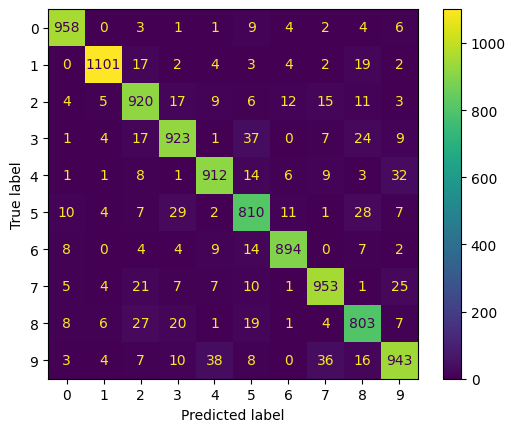

In [ ]:
confusion = confusion_matrix(predictions, y_test)
ConfusionMatrixDisplay(confusion).plot()

In our case, the model most frequently confuses 9s with 4s and 7s, which is visually intuitive given how similar these digits can look when handwritten.